# Proyek Analisis Data: oil-and-gas-summary-production-data-1967
- **Nama:** Diftha Ariangga Firdaus
- **Email:** difthadaus@gmail.com

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren produksi minyak dan gas per tahun selama periode analisis?

2. County mana yang memiliki produksi minyak dan gas tertinggi selama periode analisis?

3. Operator mana yang memiliki produksi minyak dan gas tertinggi selama periode analisis?

4. Bagaimana hubungan antara jumlah sumur aktif dengan produksi minyak dan gas?

5. Formasi geologi mana yang memiliki produksi minyak dan gas tertinggi selama periode analisis?

## Import Semua Packages/Library yang Digunakan

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

## Data Wrangling

### Gathering Data

Memuat data oil dan gas

In [66]:
#read datal"
data= pd.read_csv("oil-and-gas-summary-production-data-1967.csv",sep=",")
data.head()

,Production Year,Production Date Entered,Operator,County,Town,Field,Producing Formation,Active Oil Wells,Inactive Oil Wells,Active Gas Wells,Inactive Gas Wells,Injection Wells,Disposal Wells,Self-use Well,"Oil Produced, bbl","Gas Produced, Mcf","Water produced, bbl","Taxable Gas, Mcf",Purchaser Codes,Location
0,1995,12/3/1996,"Buffalo China, Inc.",Erie,BUFFALO,BUFFALO,MEDINA,0,0,1,0,0,0,YES,0,106,0,0,NaN,"BUFFALO, NY\n(42.887691, -78.879374)"
1,1995,3/29/1996,"Copper Ridge Oil, Inc.",Steuben,WEST UNION,BEECH HILL-INDEPENDENCE,FULMER VALLEY,28,0,0,0,7,0,NO,1229,0,180,0,OA,"WEST UNION, NY\n(42.094951, -77.725816)"
2,1994,2/14/1995,"White, Walter W. & Christina L.",Cattaraugus,CARROLLTON,BRADFORD,BRADFORD,3,0,0,0,0,0,NO,462,0,0,0,OA,"CARROLLTON, NY\n(42.023289, -78.628438)"
3,1994,1/19/1995,"Stiegler, Richard M",Erie,CHEEKTOWAGA,BUFFALO,MEDINA,0,0,1,0,0,0,YES,0,530,0,0,NaN,"CHEEKTOWAGA, NY\n(42.907071, -78.754318)"
4,1995,2/12/1996,"Bucher, Charles J",Cattaraugus,ALLEGANY,FIVE MILE,BRADFORD,10,0,0,0,0,0,NO,45,0,80,0,OA,"ALLEGANY, NY\n(42.088061, -78.491258)"


In [67]:
trend = data.groupby("Production Year")[["Oil Produced, bbl","Gas Produced, Mcf"]].sum()

print(trend)

                 Oil Produced, bbl  Gas Produced, Mcf
Production Year                                      
1967                       1584633            4278627
1968                       1486187            3823258
1969                       1236616            4750751
1970                       1112484            2993279
1971                        978535            2009426
1972                        921323            3251817
1973                        952613            5344028
1974                        865116            5229338
1975                        865205            7637743
1976                        989213            9673830
1977                        808785           10978281
1978                        863157           14053759
1979                       1038663           15256854
1980                        900267           15439966
1981                        799450           19676757
1982                        845723           18038685
1983                        

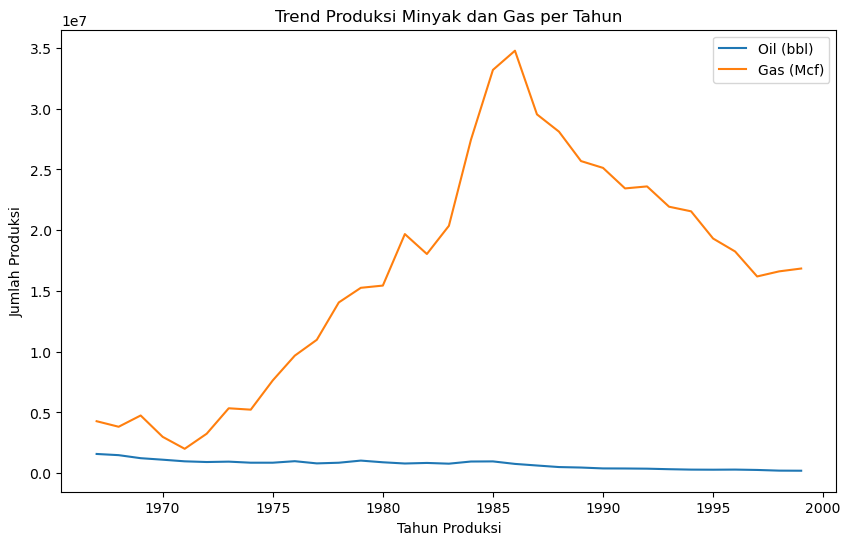

In [68]:
trend.plot(figsize=(10,6))

plt.title("Trend Produksi Minyak dan Gas per Tahun")
plt.xlabel("Tahun Produksi")
plt.ylabel("Jumlah Produksi")
plt.legend(["Oil (bbl)", "Gas (Mcf)"])
plt.show()

In [69]:
import pandas as pd
import re

# ambil koordinat
data["Latitude"] = data["Location"].str.extract(r'\((.*?),')[0]
data["Longitude"] = data["Location"].str.extract(r',\s(.*?)\)')[0]

# ubah ke numeric
data["Latitude"] = pd.to_numeric(data["Latitude"])
data["Longitude"] = pd.to_numeric(data["Longitude"])

print(data[["Latitude","Longitude"]].head())

    Latitude  Longitude
0  42.887691 -78.879374
1  42.094951 -77.725816
2  42.023289 -78.628438
3  42.907071 -78.754318
4  42.088061 -78.491258


In [70]:
center = [data["Latitude"].mean(), data["Longitude"].mean()]

map_energy = folium.Map(location=center, zoom_start=6)

for _, row in data.iterrows():

    # minyak (biru)
    if row["Oil Produced, bbl"] > 0:
        folium.CircleMarker(
            location=[row["Latitude"], row["Longitude"]],
            radius=4,
            color="blue",
            fill=True,
            fill_color="blue",
            popup=f"Oil: {row['Oil Produced, bbl']}"
        ).add_to(map_energy)

    # gas (merah)
    if row["Gas Produced, Mcf"] > 0:
        folium.CircleMarker(
            location=[row["Latitude"], row["Longitude"]],
            radius=4,
            color="red",
            fill=True,
            fill_color="red",
            popup=f"Gas: {row['Gas Produced, Mcf']}"
        ).add_to(map_energy)

map_energy

map_energy.save("peta_energy.html")